# Exploratory Data Analysis (EDA): `transaction_data.csv`

This notebook explores transaction behavior with a focus on:

- data quality and missing values
- transaction value and quantity distributions
- country-level patterns
- time-based trends (hour/day/month)
- top products and users
- return/cancellation patterns

> Note: the dataset is very large, so a row cap is configurable for faster iteration.

In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [15]:
# Config
CSV_PATH = "transaction_data.csv"
NROWS = 300_000  # set to None to read full file
RANDOM_SEED = 42

raw_df = pd.read_csv(CSV_PATH, nrows=NROWS)
print(f"Loaded shape: {raw_df.shape}")
raw_df.head()

Loaded shape: (300000, 8)


,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom


In [16]:
# Basic schema and null profile
raw_df.info()

nulls = raw_df.isna().sum().sort_values(ascending=False)
null_pct = (nulls / len(raw_df) * 100).round(2)
null_report = pd.DataFrame({"null_count": nulls, "null_pct": null_pct})
null_report

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 8 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   UserId                  300000 non-null  int64  
 1   TransactionId           300000 non-null  int64  
 2   TransactionTime         300000 non-null  object 
 3   ItemCode                300000 non-null  int64  
 4   ItemDescription         299174 non-null  object 
 5   NumberOfItemsPurchased  300000 non-null  int64  
 6   CostPerItem             300000 non-null  float64
 7   Country                 300000 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 18.3+ MB


,null_count,null_pct
ItemDescription,826,0.28
UserId,0,0.00
TransactionId,0,0.00
TransactionTime,0,0.00
ItemCode,0,0.00
NumberOfItemsPurchased,0,0.00
CostPerItem,0,0.00
Country,0,0.00


In [17]:
# Cleaning + feature engineering

df = raw_df.copy()

# Coerce numerics
df["UserId"] = pd.to_numeric(df["UserId"], errors="coerce")
df["TransactionId"] = pd.to_numeric(df["TransactionId"], errors="coerce")
df["ItemCode"] = pd.to_numeric(df["ItemCode"], errors="coerce")
df["NumberOfItemsPurchased"] = pd.to_numeric(df["NumberOfItemsPurchased"], errors="coerce")
df["CostPerItem"] = pd.to_numeric(df["CostPerItem"], errors="coerce")

# Parse timestamp format like "Sat Feb 02 12:50:00 IST 2019"
df["TransactionTimeParsed"] = pd.to_datetime(df["TransactionTime"], errors="coerce", utc=False)

# Derived fields
df["TotalValue"] = df["NumberOfItemsPurchased"] * df["CostPerItem"]
df["AbsTotalValue"] = df["TotalValue"].abs()
df["IsGuestOrUnknownUser"] = (df["UserId"] == -1).astype(int)
df["IsReturnOrCancellation"] = (df["NumberOfItemsPurchased"] < 0).astype(int)

# Time fields
parsed = df["TransactionTimeParsed"]
df["Hour"] = parsed.dt.hour
df["DayOfWeek"] = parsed.dt.day_name()
df["Month"] = parsed.dt.to_period("M").astype(str)

print(f"Cleaned shape: {df.shape}")
df.head()

Cleaned shape: (300000, 16)


,UserId,TransactionId,TransactionTime,ItemCode,ItemDescription,NumberOfItemsPurchased,CostPerItem,Country,TransactionTimeParsed,TotalValue,AbsTotalValue,IsGuestOrUnknownUser,IsReturnOrCancellation,Hour,DayOfWeek,Month
0,278166,6355745,Sat Feb 02 12:50:00 IST 2019,465549,FAMILY ALBUM WHITE PICTURE FRAME,6,11.73,United Kingdom,2019-02-02 12:50:00,70.38,70.38,0,0,12,Saturday,2019-02
1,337701,6283376,Wed Dec 26 09:06:00 IST 2018,482370,LONDON BUS COFFEE MUG,3,3.52,United Kingdom,2018-12-26 09:06:00,10.56,10.56,0,0,9,Wednesday,2018-12
2,267099,6385599,Fri Feb 15 09:45:00 IST 2019,490728,SET 12 COLOUR PENCILS DOLLY GIRL,72,0.90,France,2019-02-15 09:45:00,64.80,64.80,0,0,9,Friday,2019-02
3,380478,6044973,Fri Jun 22 07:14:00 IST 2018,459186,UNION JACK FLAG LUGGAGE TAG,3,1.73,United Kingdom,2018-06-22 07:14:00,5.19,5.19,0,0,7,Friday,2018-06
4,-1,6143225,Mon Sep 10 11:58:00 IST 2018,1733592,WASHROOM METAL SIGN,3,3.40,United Kingdom,2018-09-10 11:58:00,10.20,10.20,1,0,11,Monday,2018-09


In [18]:
# Quick summary stats
summary_cols = [
    "NumberOfItemsPurchased",
    "CostPerItem",
    "TotalValue",
    "AbsTotalValue",
    "IsGuestOrUnknownUser",
    "IsReturnOrCancellation",
]
df[summary_cols].describe(include="all").T

,count,mean,std,min,25%,50%,75%,max
NumberOfItemsPurchased,300000.0,27.525120,440.781098,-222645.00,3.00,9.00,30.00,37620.00
CostPerItem,300000.0,6.206914,105.977406,-15265.64,1.73,2.88,5.70,24614.32
TotalValue,300000.0,73.957677,782.783273,-320608.80,14.16,40.50,72.36,161335.80
AbsTotalValue,300000.0,85.667101,781.588467,0.00,15.57,41.04,73.44,320608.80
IsGuestOrUnknownUser,300000.0,0.249663,0.432819,0.00,0.00,0.00,0.00,1.00
IsReturnOrCancellation,300000.0,0.019543,0.138425,0.00,0.00,0.00,0.00,1.00


## 1) Distributions: Quantity, Price, and Transaction Value

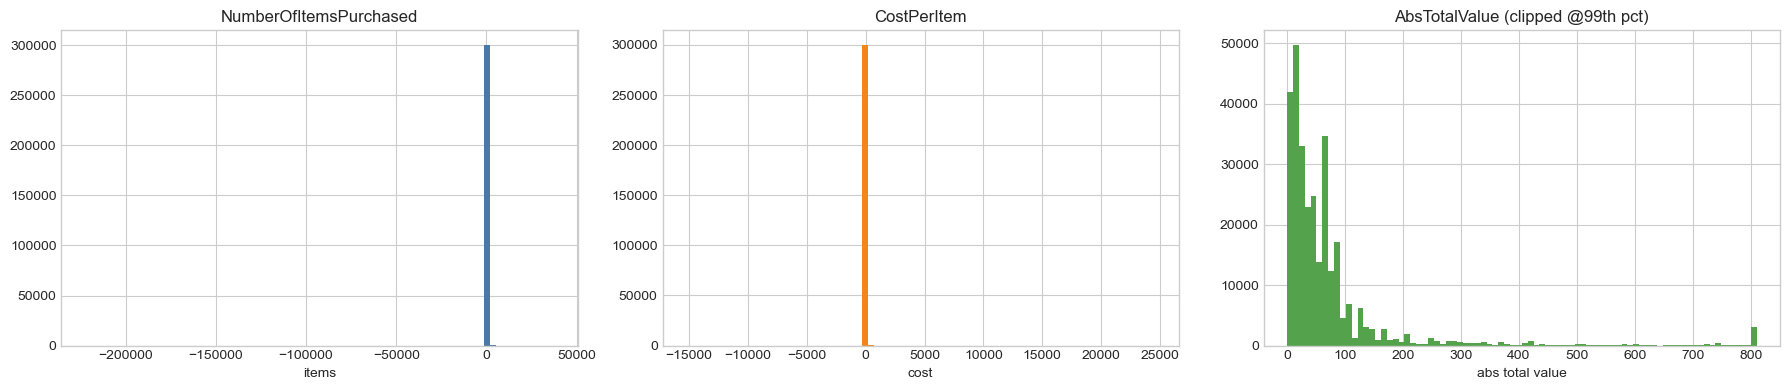

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df["NumberOfItemsPurchased"].dropna(), bins=80, color="#4C78A8")
axes[0].set_title("NumberOfItemsPurchased")
axes[0].set_xlabel("items")

axes[1].hist(df["CostPerItem"].dropna(), bins=80, color="#F58518")
axes[1].set_title("CostPerItem")
axes[1].set_xlabel("cost")

# Clip long tail for visibility
val_clip = df["AbsTotalValue"].dropna().clip(upper=df["AbsTotalValue"].quantile(0.99))
axes[2].hist(val_clip, bins=80, color="#54A24B")
axes[2].set_title("AbsTotalValue (clipped @99th pct)")
axes[2].set_xlabel("abs total value")

plt.tight_layout()
plt.show()

Return/Cancellation rate: 1.95%
Guest/Unknown user rate (UserId=-1): 24.97%


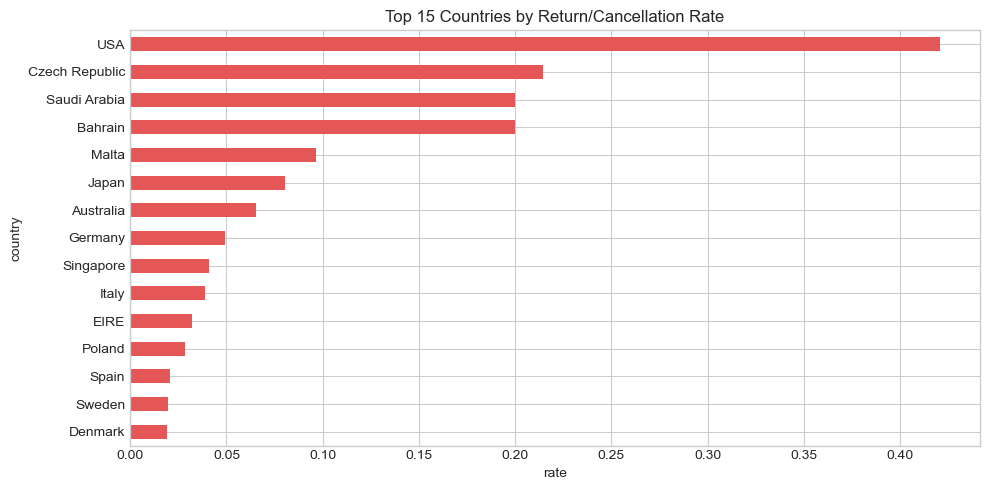

In [20]:
# Return/cancellation profile
return_rate = df["IsReturnOrCancellation"].mean() * 100
guest_rate = df["IsGuestOrUnknownUser"].mean() * 100
print(f"Return/Cancellation rate: {return_rate:.2f}%")
print(f"Guest/Unknown user rate (UserId=-1): {guest_rate:.2f}%")

ret_by_country = (
    df.groupby("Country", dropna=False)["IsReturnOrCancellation"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

plt.figure(figsize=(10, 5))
ret_by_country.sort_values().plot(kind="barh", color="#E45756")
plt.title("Top 15 Countries by Return/Cancellation Rate")
plt.xlabel("rate")
plt.ylabel("country")
plt.tight_layout()
plt.show()

## 2) Geography: Country-level transaction patterns

In [21]:
country_agg = (
    df.groupby("Country", dropna=False)
      .agg(
          transactions=("TransactionId", "count"),
          total_items=("NumberOfItemsPurchased", "sum"),
          total_value=("TotalValue", "sum"),
          avg_value=("TotalValue", "mean"),
      )
      .sort_values("transactions", ascending=False)
)
country_agg.head(10)

,transactions,total_items,total_value,avg_value
Country,,,,
United Kingdom,274327,6747456,18656248.20,68.007335
Germany,5155,196725,492386.04,95.516206
France,4758,187008,439029.87,92.271936
EIRE,4432,233166,574869.06,129.708723
Spain,1467,45030,132464.73,90.296339
Netherlands,1250,309900,636223.02,508.978416
Belgium,1179,41163,97009.44,82.281120
Switzerland,1153,51825,128328.48,111.299636
Portugal,879,26913,65317.74,74.309147


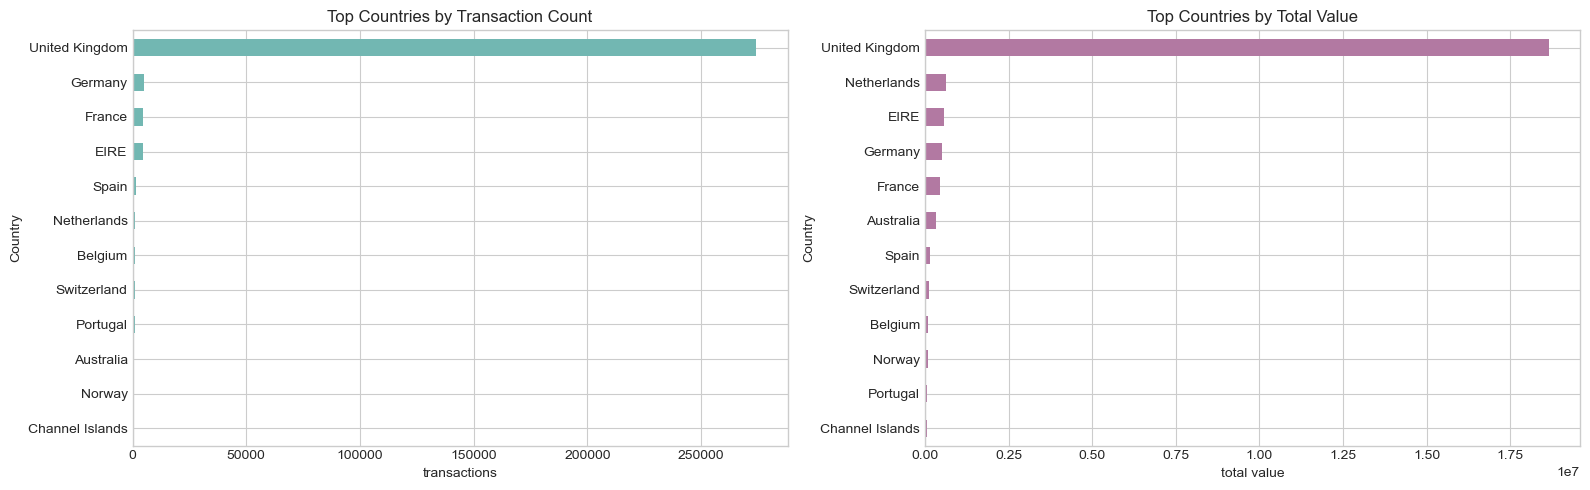

In [22]:
top_countries = country_agg.head(12).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_countries["transactions"].sort_values().plot(kind="barh", ax=axes[0], color="#72B7B2")
axes[0].set_title("Top Countries by Transaction Count")
axes[0].set_xlabel("transactions")

(top_countries["total_value"]
 .sort_values()
 .plot(kind="barh", ax=axes[1], color="#B279A2"))
axes[1].set_title("Top Countries by Total Value")
axes[1].set_xlabel("total value")

plt.tight_layout()
plt.show()

## 3) Time analysis: Hourly, weekday, and monthly trends

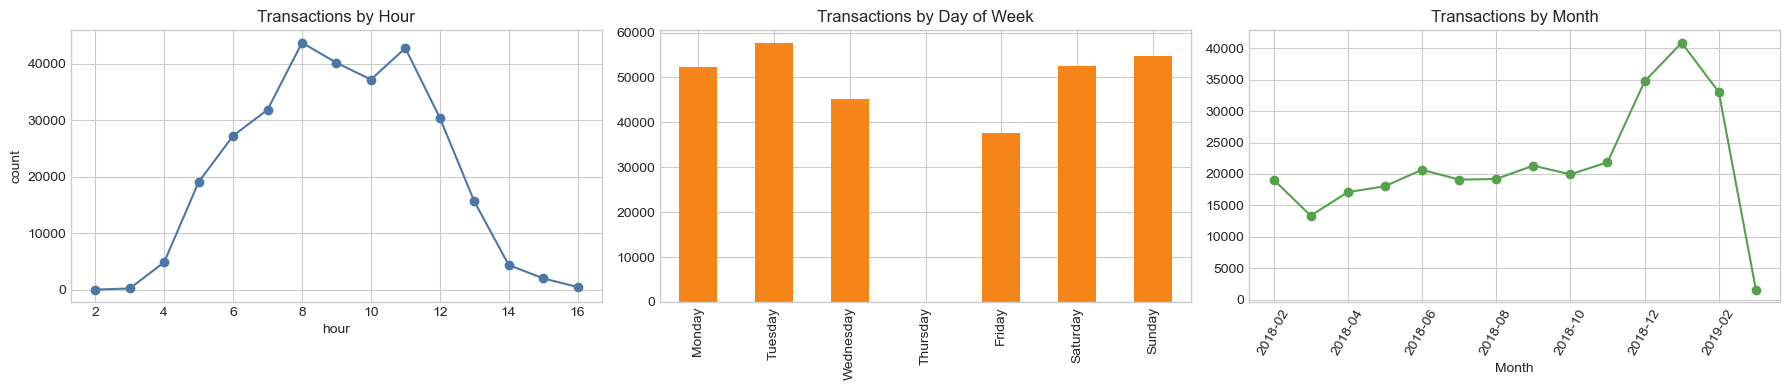

In [23]:
hourly = df.groupby("Hour")["TransactionId"].count()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = df.groupby("DayOfWeek")["TransactionId"].count().reindex(weekday_order)
monthly = df.groupby("Month")["TransactionId"].count().sort_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

hourly.plot(ax=axes[0], marker="o", color="#4C78A8")
axes[0].set_title("Transactions by Hour")
axes[0].set_xlabel("hour")
axes[0].set_ylabel("count")

weekday.plot(kind="bar", ax=axes[1], color="#F58518")
axes[1].set_title("Transactions by Day of Week")
axes[1].set_xlabel("")

monthly.plot(ax=axes[2], marker="o", color="#54A24B")
axes[2].set_title("Transactions by Month")
axes[2].tick_params(axis="x", rotation=60)

plt.tight_layout()
plt.show()

## 4) Product and user behavior

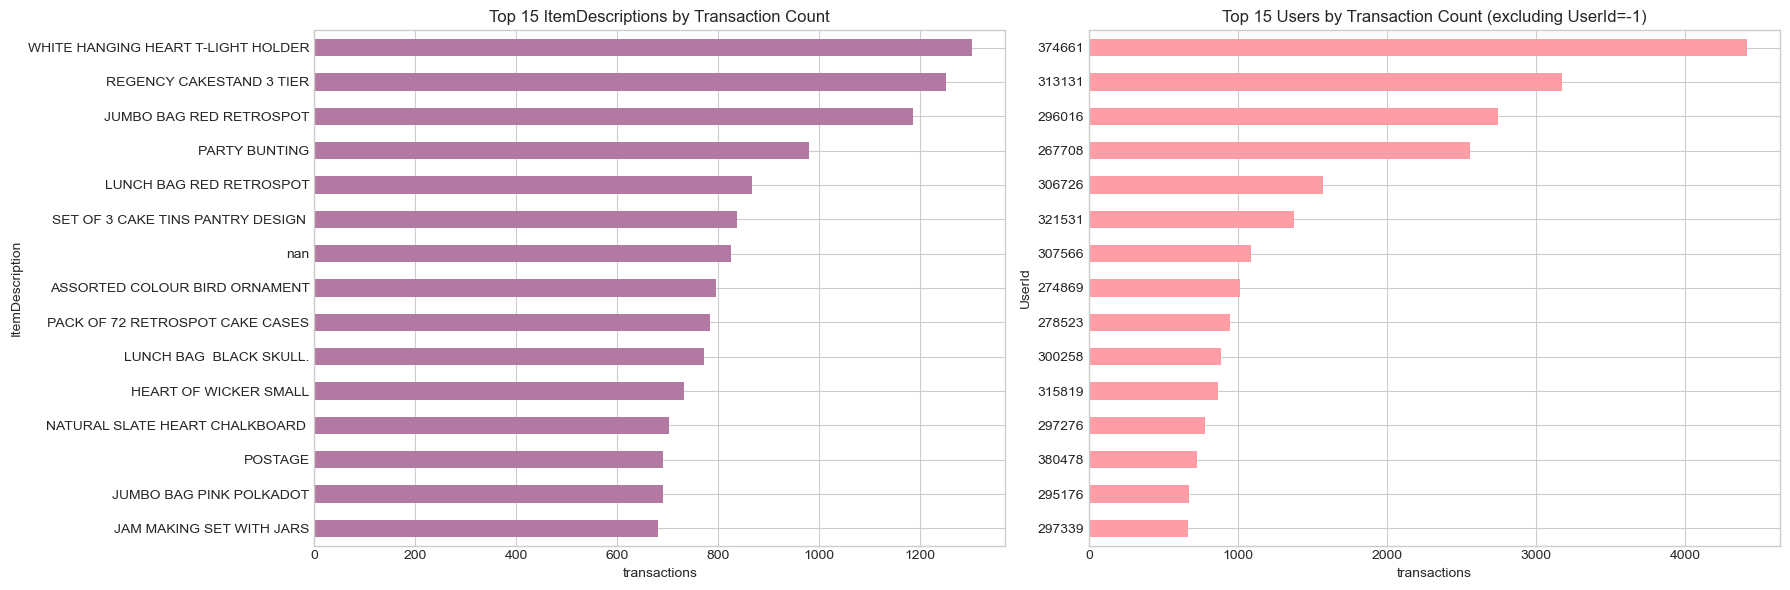

(                                    transactions  total_items
 ItemDescription                                              
 WHITE HANGING HEART T-LIGHT HOLDER          1304        52665
 REGENCY CAKESTAND 3 TIER                    1252        20433
 JUMBO BAG RED RETROSPOT                     1187        80382
 PARTY BUNTING                                980        29472
 LUNCH BAG RED RETROSPOT                      867        28164,
         transactions      spend
 UserId                         
 374661          4416   91495.77
 313131          3171  299973.42
 296016          2747  138709.29
 267708          2558   68027.67
 306726          1568   28037.34)

In [24]:
top_items = (
    df.groupby("ItemDescription", dropna=False)
      .agg(transactions=("TransactionId", "count"), total_items=("NumberOfItemsPurchased", "sum"))
      .sort_values("transactions", ascending=False)
      .head(15)
)

top_users = (
    df[df["UserId"] != -1]
      .groupby("UserId")
      .agg(transactions=("TransactionId", "count"), spend=("TotalValue", "sum"))
      .sort_values("transactions", ascending=False)
      .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_items["transactions"].sort_values().plot(kind="barh", ax=axes[0], color="#B279A2")
axes[0].set_title("Top 15 ItemDescriptions by Transaction Count")
axes[0].set_xlabel("transactions")

(top_users["transactions"].sort_values().plot(kind="barh", ax=axes[1], color="#FF9DA6"))
axes[1].set_title("Top 15 Users by Transaction Count (excluding UserId=-1)")
axes[1].set_xlabel("transactions")

plt.tight_layout()
plt.show()

top_items.head(), top_users.head()

## 5) Outliers and correlation

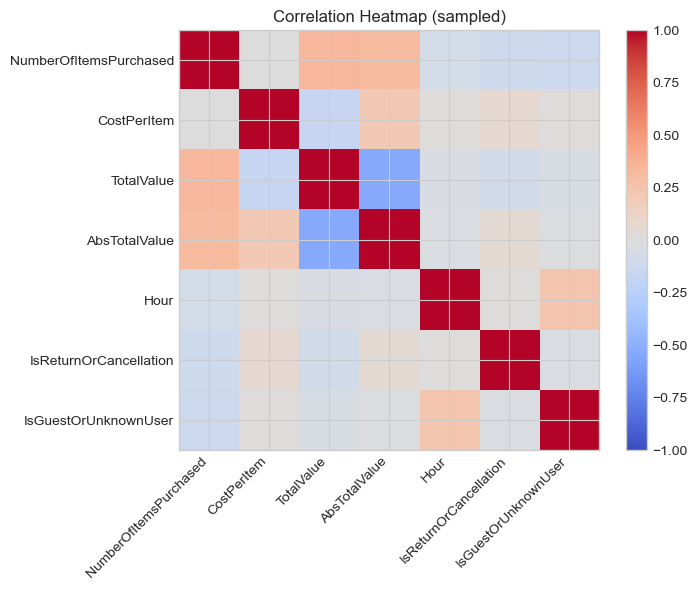

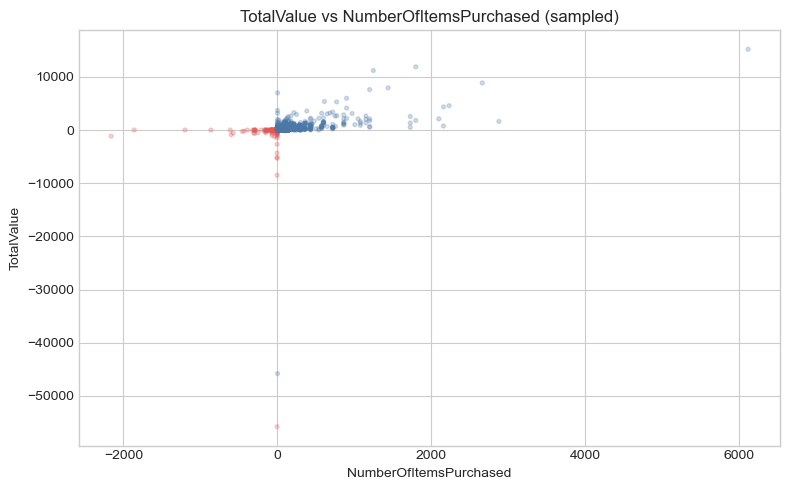

In [25]:
numeric_cols = ["NumberOfItemsPurchased", "CostPerItem", "TotalValue", "AbsTotalValue", "Hour", "IsReturnOrCancellation", "IsGuestOrUnknownUser"]

sample_df = df[numeric_cols].dropna().sample(min(20000, len(df)), random_state=RANDOM_SEED)

# Correlation matrix heatmap (matplotlib only)
corr = sample_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
ax.set_title("Correlation Heatmap (sampled)")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Scatter for value vs quantity (sampled)
scatter_df = df[["NumberOfItemsPurchased", "TotalValue", "IsReturnOrCancellation"]].dropna().sample(min(15000, len(df)), random_state=RANDOM_SEED)
colors = np.where(scatter_df["IsReturnOrCancellation"] == 1, "#E45756", "#4C78A8")

plt.figure(figsize=(8, 5))
plt.scatter(scatter_df["NumberOfItemsPurchased"], scatter_df["TotalValue"], s=8, alpha=0.25, c=colors)
plt.title("TotalValue vs NumberOfItemsPurchased (sampled)")
plt.xlabel("NumberOfItemsPurchased")
plt.ylabel("TotalValue")
plt.tight_layout()
plt.show()

## 6) Key takeaways (auto-generated checks)

Run the cell below after executing all plots to print compact EDA observations.

In [26]:
top_country = country_agg.index[0] if len(country_agg) else "NA"
ret_rate = df["IsReturnOrCancellation"].mean() * 100
guest_rate = df["IsGuestOrUnknownUser"].mean() * 100

print("EDA quick observations")
print("-" * 60)
print(f"Rows analyzed: {len(df):,}")
print(f"Top country by transactions: {top_country}")
print(f"Return/Cancellation rate: {ret_rate:.2f}%")
print(f"Guest/Unknown user rate: {guest_rate:.2f}%")
print(f"Median quantity: {df['NumberOfItemsPurchased'].median():.2f}")
print(f"Median cost/item: {df['CostPerItem'].median():.2f}")
print(f"Median abs transaction value: {df['AbsTotalValue'].median():.2f}")

EDA quick observations
------------------------------------------------------------
Rows analyzed: 300,000
Top country by transactions: United Kingdom
Return/Cancellation rate: 1.95%
Guest/Unknown user rate: 24.97%
Median quantity: 9.00
Median cost/item: 2.88
Median abs transaction value: 41.04
